In [2]:
import duckdb
import pandas as pd
import itertools
from pathlib import Path

PROJECT_ROOT = Path(r'C:\Users\Tobi\Desktop\CSHW\TransitKPIFramework')
DB_PATH      = PROJECT_ROOT / 'data' / 'transit_kpi.duckdb'

con = duckdb.connect(str(DB_PATH))

print(f'Database: {DB_PATH}')
print()
print('Tables:')
print(con.sql('SHOW TABLES').df().to_string(index=False))

Database: C:\Users\Tobi\Desktop\CSHW\TransitKPIFramework\data\transit_kpi.duckdb

Tables:
                   name
               calendar
         calendar_dates
                 gtfsrt
          matched_stops
     otp_specifications
             stop_times
            trip_delays
    trip_delays_closest
trip_delays_last_before
     trip_delays_latest
                  trips


In [3]:
required = ['trip_delays_closest', 'trip_delays_last_before', 'trip_delays_latest']
existing = set(con.sql('SHOW TABLES').df()['name'].tolist())
missing = [t for t in required if t not in existing]
if missing:
    raise RuntimeError(
        f'Missing required tables: {missing}. Run notebook 03 first.'
    )

print('Snapshot rule tables:')
for t in required:
    n = con.sql(f'SELECT COUNT(*) FROM {t}').fetchone()[0]
    print(f'  {t:30s} {n:>10,} rows')

print()
print('Date coverage check (hours of archived data per service_date):')
print(con.sql("""
    SELECT
        service_date,
        ROUND((MAX(predicted_unix) - MIN(predicted_unix)) / 3600.0, 1) AS span_hours
    FROM trip_delays_latest
    GROUP BY service_date
    ORDER BY service_date
""").df().to_string(index=False))

Snapshot rule tables:
  trip_delays_closest               745,669 rows
  trip_delays_last_before           729,768 rows
  trip_delays_latest                745,669 rows

Date coverage check (hours of archived data per service_date):
service_date  span_hours
  2026-04-04         5.4
  2026-04-05        20.6
  2026-04-06        24.4
  2026-04-07        24.5
  2026-04-08        24.5
  2026-04-09        24.4
  2026-04-10        21.1
  2026-04-11        21.1
  2026-04-12        20.7
  2026-04-13        24.5
  2026-04-14        24.4
  2026-04-15        24.5
  2026-04-16        24.4
  2026-04-17        20.8
  2026-04-18        20.9
  2026-04-19        20.7
  2026-04-20        24.4
  2026-04-21        24.5
  2026-04-22        24.7
  2026-04-23        24.5
  2026-04-24        20.9
  2026-04-25        12.0


In [3]:
# Each dimension is defined as a list of variants. The full specification
# cross-product is generated below.
#
# Following Simonsohn et al. 2020 and Steegen et al. 2016, every variant
# included here is theoretically justified, statistically valid, and
# non-redundant with the others. Variants that are clearly inferior to
# alternatives are not included.

snapshot_rules = [
    {'name': 'closest',     'table': 'trip_delays_closest'},
    {'name': 'last_before', 'table': 'trip_delays_last_before'},
    {'name': 'latest',      'table': 'trip_delays_latest'},
]

lateness_windows = [
    {'name': '0_3',     'lower':  0, 'upper': 3},
    {'name': 'neg1_5',  'lower': -1, 'upper': 5},
    {'name': 'neg2_7',  'lower': -2, 'upper': 7},
]

early_treatments = [
    {'name': 'count_early_as_late'},
    {'name': 'ignore_early'},
]

stop_selections = [
    {'name': 'all_stops',       'sql': None},
    {'name': 'timepoints_only', 'sql': 'timepoint = 1'},
    {'name': 'terminals_only',  'sql': (
        'stop_sequence IN ('
        '  SELECT MIN(stop_sequence) FROM stop_times st WHERE st.trip_id = td.trip_id'
        ') OR stop_sequence IN ('
        '  SELECT MAX(stop_sequence) FROM stop_times st WHERE st.trip_id = td.trip_id'
        ')'
    )},
]

times_of_day = [
    {'name': 'am_peak', 'sql': 'scheduled_arrival_seconds >= 25200 AND scheduled_arrival_seconds < 32400'},
    {'name': 'midday',  'sql': 'scheduled_arrival_seconds >= 32400 AND scheduled_arrival_seconds < 57600'},
    {'name': 'pm_peak', 'sql': 'scheduled_arrival_seconds >= 57600 AND scheduled_arrival_seconds < 64800'},
    {'name': 'evening', 'sql': 'scheduled_arrival_seconds >= 64800 AND scheduled_arrival_seconds < 75600'},
    {'name': 'all_day', 'sql': None},
]

delay_bases = [
    {'name': 'arrival'},
    {'name': 'departure'},
]

routes = ['23', '47']

specs = []
for sr, lw, et, ss, tod, db, rt in itertools.product(
    snapshot_rules, lateness_windows, early_treatments,
    stop_selections, times_of_day, delay_bases, routes
):
    specs.append({
        'snapshot_rule':    sr['name'],
        'snapshot_table':   sr['table'],
        'lateness_window':  lw['name'],
        'window_lower':     lw['lower'],
        'window_upper':     lw['upper'],
        'early_treatment':  et['name'],
        'stop_selection':   ss['name'],
        'stop_sql':         ss['sql'],
        'time_of_day':      tod['name'],
        'tod_sql':          tod['sql'],
        'delay_basis':      db['name'],
        'route_id':         rt,
    })

print(f'Total specifications: {len(specs)}')
print(f'Per route:            {len(specs) // len(routes)}')
print()
print('Dimension cardinalities:')
print(f'  snapshot_rules:    {len(snapshot_rules)}')
print(f'  lateness_windows:  {len(lateness_windows)}')
print(f'  early_treatments:  {len(early_treatments)}')
print(f'  stop_selections:   {len(stop_selections)}')
print(f'  times_of_day:      {len(times_of_day)}')
print(f'  delay_bases:       {len(delay_bases)}')
print(f'  routes:            {len(routes)}')

Total specifications: 1080
Per route:            540

Dimension cardinalities:
  snapshot_rules:    3
  lateness_windows:  3
  early_treatments:  2
  stop_selections:   3
  times_of_day:      5
  delay_bases:       2
  routes:            2


In [4]:
# Build and execute one query per specification. Each query computes
# n_events, n_on_time, and otp_pct under the specification's filters.

def build_query(spec):
    table = spec['snapshot_table']
    rt    = spec['route_id']
    lo    = spec['window_lower']
    hi    = spec['window_upper']

    if spec['delay_basis'] == 'arrival':
        delay_expr = 'delay_minutes'
    else:
        delay_expr = (
            'ROUND((predicted_unix - '
            '(scheduled_unix + scheduled_departure_seconds - scheduled_arrival_seconds))'
            ' / 60.0, 1)'
        )

    if spec['early_treatment'] == 'count_early_as_late':
        on_time_cond = f'{delay_expr} BETWEEN {lo} AND {hi}'
    else:
        on_time_cond = f'{delay_expr} <= {hi}'

    where = [
        f"route_id = '{rt}'",
        'ISODOW(CAST(service_date AS DATE)) BETWEEN 1 AND 5',  # weekdays only
    ]
    if spec['tod_sql']:
        where.append(spec['tod_sql'])
    if spec['stop_sql']:
        where.append(spec['stop_sql'])

    where_clause = ' AND '.join(where)

    sql = f"""
        SELECT
            COUNT(*) AS n_events,
            SUM(CASE WHEN {on_time_cond} THEN 1 ELSE 0 END) AS n_on_time
        FROM {table} td
        WHERE {where_clause}
    """
    return sql

results = []
for i, spec in enumerate(specs):
    if i % 100 == 0:
        print(f'  running spec {i}/{len(specs)}...')
    sql = build_query(spec)
    row = con.sql(sql).fetchone()
    n_events, n_on_time = row
    results.append({
        'snapshot_rule':   spec['snapshot_rule'],
        'lateness_window': spec['lateness_window'],
        'early_treatment': spec['early_treatment'],
        'stop_selection':  spec['stop_selection'],
        'time_of_day':     spec['time_of_day'],
        'delay_basis':     spec['delay_basis'],
        'route_id':        spec['route_id'],
        'n_events':        n_events,
        'n_on_time':       n_on_time,
        'otp_pct':         (round(n_on_time * 100.0 / n_events, 2)
                            if n_events > 0 else None),
    })

df = pd.DataFrame(results)

def reliability(n):
    if n is None or n < 1000:
        return 'drop'
    elif n < 5000:
        return 'flag'
    else:
        return 'ok'

df['tier'] = df['n_events'].apply(reliability)

print()
print(f'Total specifications run: {len(df)}')
print('Tier distribution:')
print(df['tier'].value_counts().to_string())

  running spec 0/1080...
  running spec 100/1080...
  running spec 200/1080...
  running spec 300/1080...
  running spec 400/1080...
  running spec 500/1080...
  running spec 600/1080...
  running spec 700/1080...
  running spec 800/1080...
  running spec 900/1080...
  running spec 1000/1080...

Total specifications run: 1080
Tier distribution:
tier
ok      864
flag    216


In [5]:
kept = df[df['tier'] != 'drop'].copy()

con.execute('DROP TABLE IF EXISTS otp_specifications')
con.execute('CREATE TABLE otp_specifications AS SELECT * FROM kept')

print('otp_specifications table:')
print(con.sql('SELECT COUNT(*) AS rows FROM otp_specifications').df().to_string(index=False))
print()
print('Tier breakdown of kept specifications:')
print(con.sql("""
    SELECT tier, COUNT(*) AS specs
    FROM otp_specifications
    GROUP BY tier
""").df().to_string(index=False))

otp_specifications table:
 rows
 1080

Tier breakdown of kept specifications:
tier  specs
  ok    864
flag    216


In [6]:
# Per Simonsohn et al. 2020, singling out one specification as 'the'
# answer is what the framework is meant to avoid. Instead we report
# the DISTRIBUTION of OTP across defensible specifications.
#
# If the paper needs to cite a single number, cite the median with the
# explicit caveat that it is the median of N defensible specifications,
# not 'the' OTP for the route.

print('Distribution of OTP across defensible specifications, by route:')
print(con.sql("""
    SELECT
        route_id,
        COUNT(*) AS n_specs,
        ROUND(MIN(otp_pct), 1)                  AS min_otp,
        ROUND(QUANTILE_CONT(otp_pct, 0.25), 1)  AS q25_otp,
        ROUND(MEDIAN(otp_pct), 1)               AS median_otp,
        ROUND(QUANTILE_CONT(otp_pct, 0.75), 1)  AS q75_otp,
        ROUND(MAX(otp_pct), 1)                  AS max_otp,
        ROUND(MAX(otp_pct) - MIN(otp_pct), 1)   AS range_pp,
        ROUND(STDDEV(otp_pct), 1)               AS stddev_otp
    FROM otp_specifications
    WHERE tier = 'ok'
    GROUP BY route_id
    ORDER BY route_id
""").df().to_string(index=False))

print()
print('---')
print('Comparison slice: how does the snapshot rule alone shift OTP?')
print('All other dimensions held at one defensible setting')
print('(neg1_5 + count_early_as_late + all_stops + all_day + arrival).')
print('This is one slice, not THE answer.')
print()
print(con.sql("""
    SELECT snapshot_rule, route_id, n_events, otp_pct
    FROM otp_specifications
    WHERE lateness_window = 'neg1_5'
      AND early_treatment = 'count_early_as_late'
      AND stop_selection = 'all_stops'
      AND time_of_day = 'all_day'
      AND delay_basis = 'arrival'
    ORDER BY route_id, snapshot_rule
""").df().to_string(index=False))

Distribution of OTP across defensible specifications, by route:
route_id  n_specs  min_otp  q25_otp  median_otp  q75_otp  max_otp  range_pp  stddev_otp
      23      432     20.3     53.2        67.0     85.1     99.8      79.5        20.7
      47      432     20.3     47.6        60.0     80.9     99.3      79.0        20.9

---
Comparison slice: how does the snapshot rule alone shift OTP?
All other dimensions held at one defensible setting
(neg1_5 + count_early_as_late + all_stops + all_day + arrival).
This is one slice, not THE answer.

snapshot_rule route_id  n_events  otp_pct
      closest       23    302719    87.37
  last_before       23    296541    60.67
       latest       23    302719    55.98
      closest       47    297486    86.17
  last_before       47    291434    55.90
       latest       47    297486    48.81


In [7]:
# Sensitivity decomposition: how much does varying each dimension move OTP,
# holding all other dimensions fixed?
#
# Method: for each combination of all-other-dimensions, compute the range
# (max - min) of OTP across the focal dimension's variants. Then take the
# mean of those ranges across combinations. Larger mean range = more
# sensitivity to that dimension.
#
# Note: this is NOT a formal ANOVA-style variance decomposition. It is a
# descriptive sensitivity analysis aligned with the dashboard panel of a
# specification curve plot (Simonsohn et al. 2020 Figure 2 bottom).

dims = ['snapshot_rule', 'lateness_window', 'early_treatment',
        'stop_selection', 'time_of_day', 'delay_basis']

kept = con.sql("SELECT * FROM otp_specifications WHERE tier = 'ok'").df()

print('Sensitivity to each dimension (mean OTP range when varying that')
print('dimension while holding all others fixed):')
print()
summary = []
for d in dims:
    other_dims = [x for x in dims if x != d] + ['route_id']
    grouped = kept.groupby(other_dims)['otp_pct']
    ranges = grouped.max() - grouped.min()
    summary.append({
        'dimension':       d,
        'mean_range_pp':   round(ranges.mean(), 2),
        'median_range_pp': round(ranges.median(), 2),
        'max_range_pp':    round(ranges.max(), 2),
        'n_combinations':  len(ranges),
    })

summary_df = pd.DataFrame(summary).sort_values('mean_range_pp', ascending=False)
print(summary_df.to_string(index=False))
print()
print('Interpretation: the dimension with the largest mean range has the')
print('strongest effect on reported OTP. Dimensions ranked low contribute')
print('relatively little to the spread of defensible answers.')

Sensitivity to each dimension (mean OTP range when varying that
dimension while holding all others fixed):

      dimension  mean_range_pp  median_range_pp  max_range_pp  n_combinations
  snapshot_rule          30.69            30.36         50.12             288
lateness_window          27.25            28.82         46.94             288
early_treatment          14.79            11.64         48.63             432
 stop_selection           9.60             8.32         31.99             360
    time_of_day           7.48             4.07         34.39             216
    delay_basis           0.00             0.00          0.02             432

Interpretation: the dimension with the largest mean range has the
strongest effect on reported OTP. Dimensions ranked low contribute
relatively little to the spread of defensible answers.


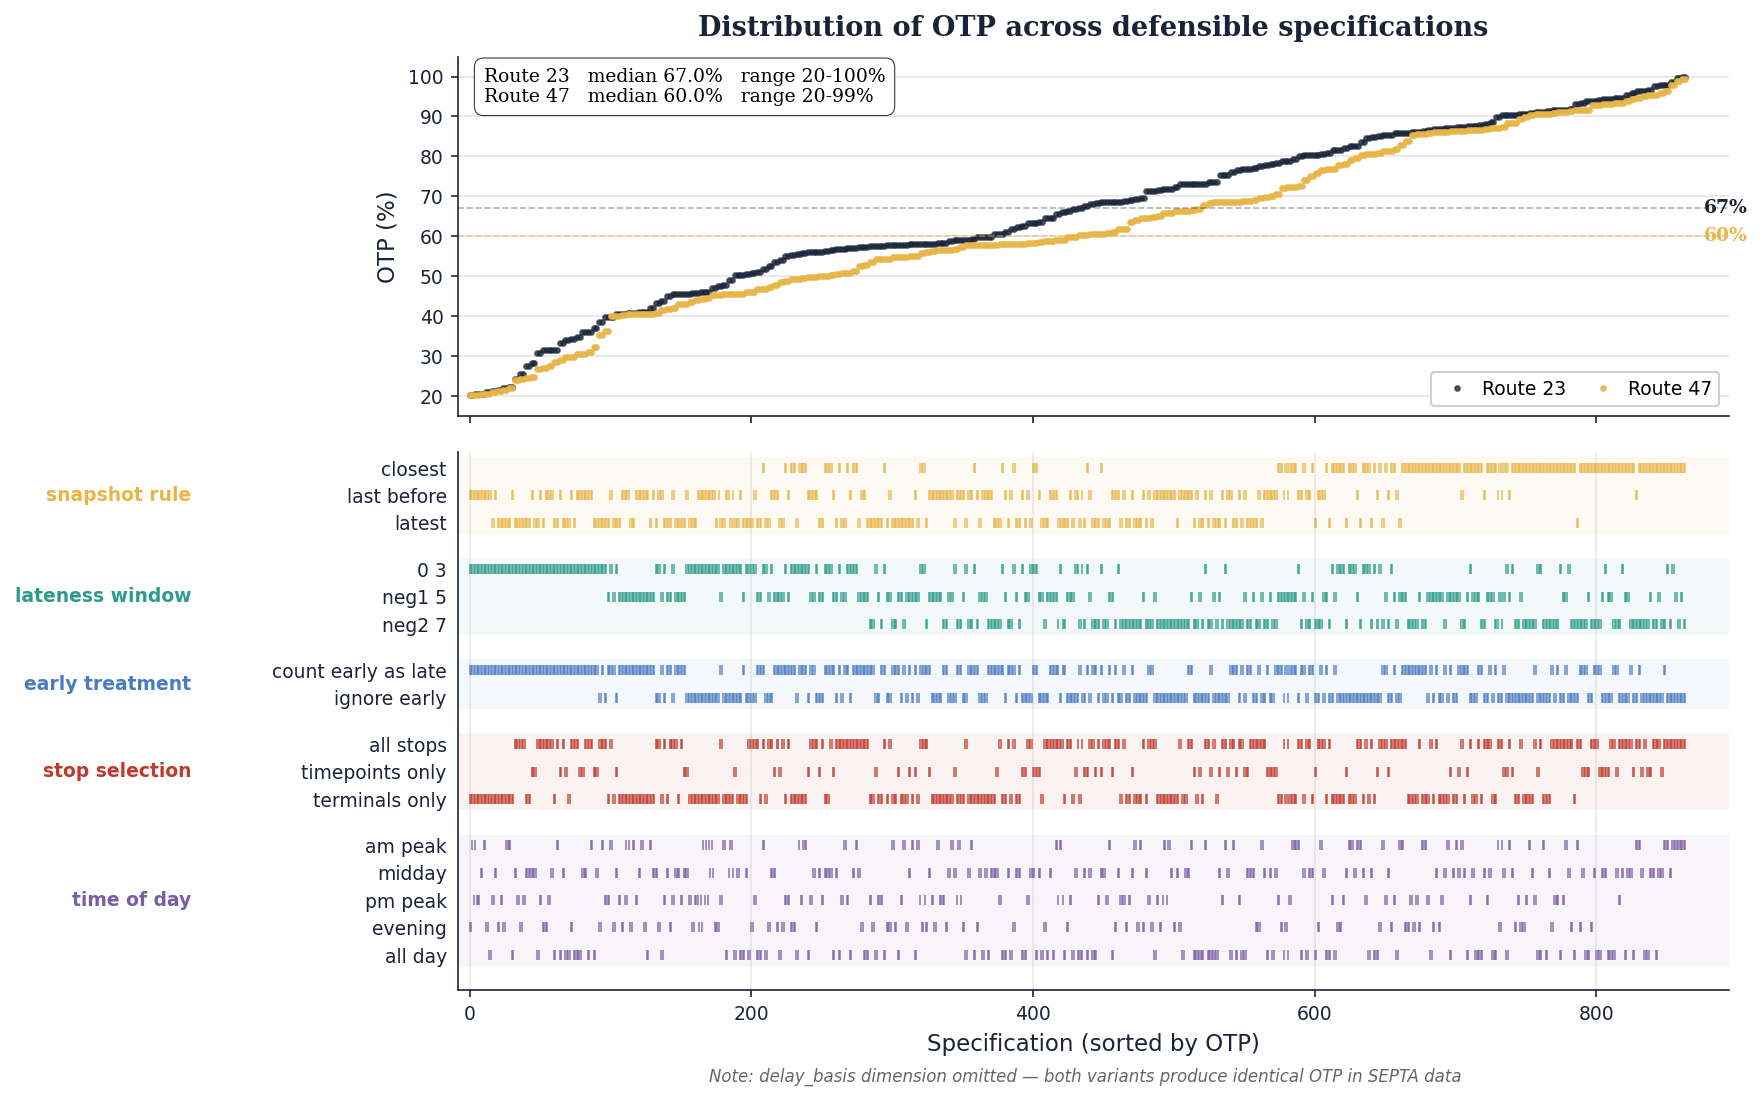

Saved to C:\Users\Tobi\Desktop\CSHW\TransitKPIFramework\docs\specification_curve.png


In [4]:
# =============================================================================
# CELL 8 — Specification curve plot (improved)
# =============================================================================
# Replaces the existing cell 8 in 04_otp_analysis.ipynb.
# Same data inputs, much more readable output.

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import numpy as np

kept = con.sql("SELECT * FROM otp_specifications WHERE tier = 'ok' ORDER BY otp_pct").df()

# Color palette
NAVY = '#1a2438'
GOLD = '#E8B547'
TEAL = '#2D9B8A'
BLUE = '#4A7BC2'
RED  = '#C0392B'
PURPLE = '#7B5CA7'

DIM_COLORS = {
    'snapshot_rule': GOLD,
    'lateness_window': TEAL,
    'early_treatment': BLUE,
    'stop_selection': RED,
    'time_of_day': PURPLE,
}

# Per-route data for top panel
route_23_otp = kept[kept['route_id'] == '23'].sort_values('otp_pct')['otp_pct'].values
route_47_otp = kept[kept['route_id'] == '47'].sort_values('otp_pct')['otp_pct'].values
median_23 = np.median(route_23_otp)
median_47 = np.median(route_47_otp)

# Combined-sorted data for bottom panel
kept_sorted = kept.sort_values('otp_pct').reset_index(drop=True)
n_specs = len(kept_sorted)

# ---------- Figure setup ----------
fig = plt.figure(figsize=(11, 7.5), dpi=150)
fig.patch.set_facecolor('white')

gs = gridspec.GridSpec(2, 1, height_ratios=[2.0, 3.0], hspace=0.08,
                       left=0.20, right=0.97, top=0.93, bottom=0.10)

# ---------- TOP PANEL: OTP curve ----------
ax_top = fig.add_subplot(gs[0])
ax_top.set_facecolor('white')

x_23_scaled = np.linspace(0, n_specs - 1, len(route_23_otp))
x_47_scaled = np.linspace(0, n_specs - 1, len(route_47_otp))

ax_top.plot(x_23_scaled, route_23_otp, '.', color=NAVY, alpha=0.7, markersize=4.5,
            label='Route 23')
ax_top.plot(x_47_scaled, route_47_otp, '.', color=GOLD, alpha=0.85, markersize=4.5,
            label='Route 47')

ax_top.axhline(median_23, color=NAVY, alpha=0.35, linestyle='--', linewidth=0.8)
ax_top.axhline(median_47, color=GOLD, alpha=0.55, linestyle='--', linewidth=0.8)

ax_top.text(n_specs + 12, median_23, f'{median_23:.0f}%', fontsize=9, color=NAVY,
            family='serif', fontweight='bold', va='center')
ax_top.text(n_specs + 12, median_47, f'{median_47:.0f}%', fontsize=9, color=GOLD,
            family='serif', fontweight='bold', va='center')

ax_top.text(0.02, 0.97,
            f'Route 23   median {median_23:.1f}%   range {route_23_otp.min():.0f}-{route_23_otp.max():.0f}%\n'
            f'Route 47   median {median_47:.1f}%   range {route_47_otp.min():.0f}-{route_47_otp.max():.0f}%',
            transform=ax_top.transAxes, fontsize=9, family='serif',
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.95,
                      edgecolor=NAVY, linewidth=0.5))

ax_top.legend(loc='lower right', fontsize=9, framealpha=0.92,
              ncol=2, handletextpad=0.3, columnspacing=1.0)
ax_top.set_ylabel('OTP (%)', fontsize=11, family='sans-serif', color=NAVY)
ax_top.set_ylim(15, 105)
ax_top.set_xlim(-8, n_specs + 30)
ax_top.grid(True, alpha=0.25, color='#999999', axis='y')
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)
ax_top.spines['left'].set_color(NAVY)
ax_top.spines['bottom'].set_color(NAVY)
ax_top.tick_params(colors=NAVY, labelsize=9)
ax_top.set_xticklabels([])
ax_top.set_title('Distribution of OTP across defensible specifications',
                 fontsize=13, family='serif', color=NAVY, fontweight='bold',
                 pad=10)

# ---------- BOTTOM PANEL: dashboard ----------
ax_bot = fig.add_subplot(gs[1])
ax_bot.set_facecolor('white')

dimensions_order = [
    ('snapshot_rule', ['closest', 'last_before', 'latest']),
    ('lateness_window', ['0_3', 'neg1_5', 'neg2_7']),
    ('early_treatment', ['count_early_as_late', 'ignore_early']),
    ('stop_selection', ['all_stops', 'timepoints_only', 'terminals_only']),
    ('time_of_day', ['am_peak', 'midday', 'pm_peak', 'evening', 'all_day']),
]

# Calculate y positions with spacers between groups
y_positions = {}
y_pos = 0
group_labels = []

for dim, variants in dimensions_order:
    group_start = y_pos
    for v in variants:
        y_positions[(dim, v)] = y_pos
        y_pos += 1
    group_labels.append((group_start, y_pos - 1, dim))
    y_pos += 0.7

total_rows = y_pos
x_specs = np.arange(n_specs)

# Plot ticks
for dim, variants in dimensions_order:
    color = DIM_COLORS[dim]
    for v in variants:
        y = y_positions[(dim, v)]
        mask = (kept_sorted[dim] == v).values
        x_active = x_specs[mask]
        ax_bot.scatter(x_active, [y] * len(x_active),
                       marker='|', s=24, color=color, alpha=0.7,
                       linewidths=0.9)

# Background bands per dimension group
for start, end, dim in group_labels:
    color = DIM_COLORS[dim]
    rect = Rectangle((-8, start - 0.4), n_specs + 38, end - start + 0.8,
                     facecolor=color, alpha=0.06, zorder=0)
    ax_bot.add_patch(rect)

# Y-axis labels
yticks = []
yticklabels = []
for dim, variants in dimensions_order:
    for v in variants:
        yticks.append(y_positions[(dim, v)])
        yticklabels.append(v.replace('_', ' '))

ax_bot.set_yticks(yticks)
ax_bot.set_yticklabels(yticklabels, fontsize=8, family='sans-serif')

# Dimension group labels on far left
for start, end, dim in group_labels:
    mid = (start + end) / 2
    ax_bot.text(-0.21, mid, dim.replace('_', ' '),
                transform=ax_bot.get_yaxis_transform(),
                fontsize=9, family='sans-serif', fontweight='bold',
                color=DIM_COLORS[dim],
                ha='right', va='center')

ax_bot.set_xlabel('Specification (sorted by OTP)', fontsize=11,
                  family='sans-serif', color=NAVY)
ax_bot.set_xlim(-8, n_specs + 30)
ax_bot.set_ylim(-0.6, total_rows - 0.4)
ax_bot.invert_yaxis()
ax_bot.grid(True, alpha=0.2, color='#999999', axis='x', zorder=0)
ax_bot.spines['top'].set_visible(False)
ax_bot.spines['right'].set_visible(False)
ax_bot.spines['left'].set_color(NAVY)
ax_bot.spines['bottom'].set_color(NAVY)
ax_bot.tick_params(colors=NAVY, labelsize=9, left=False)
ax_bot.tick_params(axis='y', pad=2)

fig.text(0.58, 0.015,
         'Note: delay_basis dimension omitted — both variants produce identical OTP in SEPTA data',
         fontsize=8, family='sans-serif', color='#666666',
         ha='center', va='bottom', style='italic')

out_path = PROJECT_ROOT / 'docs' / 'specification_curve.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved to {out_path}')

In [9]:
# Slice analysis: for each dimension, hold all OTHER dimensions at one
# specific defensible setting and show how OTP varies as we change just
# this one dimension.
#
# IMPORTANT: this is NOT 'the' answer. It is one particular slice through
# the specification space. Different reference points may yield different
# patterns. The full distribution (cell 6) and the sensitivity decomposition
# (cell 7) are the more general summaries.

reference_point = {
    'snapshot_rule':   'latest',
    'lateness_window': 'neg1_5',
    'early_treatment': 'count_early_as_late',
    'stop_selection':  'all_stops',
    'time_of_day':     'all_day',
    'delay_basis':     'arrival',
}

print('Slice through the specification space at the reference point:')
for k, v in reference_point.items():
    print(f'  {k}: {v}')
print()
print('For each dimension, OTP varies as below when only that dimension')
print('changes from the reference point.')
print()

for varying in reference_point:
    fixed = {k: v for k, v in reference_point.items() if k != varying}
    where_clauses = [f"{k} = '{v}'" for k, v in fixed.items()]
    where_clauses.append("tier = 'ok'")
    where_sql = ' AND '.join(where_clauses)

    print(f'Varying {varying}:')
    print(con.sql(f"""
        SELECT
            {varying}, route_id, n_events, otp_pct
        FROM otp_specifications
        WHERE {where_sql}
        ORDER BY route_id, {varying}
    """).df().to_string(index=False))
    print()

Slice through the specification space at the reference point:
  snapshot_rule: latest
  lateness_window: neg1_5
  early_treatment: count_early_as_late
  stop_selection: all_stops
  time_of_day: all_day
  delay_basis: arrival

For each dimension, OTP varies as below when only that dimension
changes from the reference point.

Varying snapshot_rule:
snapshot_rule route_id  n_events  otp_pct
      closest       23    302719    87.37
  last_before       23    296541    60.67
       latest       23    302719    55.98
      closest       47    297486    86.17
  last_before       47    291434    55.90
       latest       47    297486    48.81

Varying lateness_window:
lateness_window route_id  n_events  otp_pct
            0_3       23    302719    31.59
         neg1_5       23    302719    55.98
         neg2_7       23    302719    72.98
            0_3       47    297486    27.42
         neg1_5       47    297486    48.81
         neg2_7       47    297486    64.46

Varying early_treatmen

In [10]:
con.sql("""
    SELECT 
        service_date, 
        ISODOW(CAST(service_date AS DATE)) AS dow,
        route_id, 
        COUNT(*) AS n
    FROM trip_delays_latest
    GROUP BY service_date, route_id
    ORDER BY service_date, route_id
""").df()

,service_date,dow,route_id,n
0,2026-04-04,6,23,2322
1,2026-04-04,6,47,2461
2,2026-04-05,7,23,11853
3,2026-04-05,7,47,10760
4,2026-04-06,1,23,20503
5,2026-04-06,1,47,21280
6,2026-04-07,2,23,21140
7,2026-04-07,2,47,20103
8,2026-04-08,3,23,19827
9,2026-04-08,3,47,19625


In [13]:
con.sql("""
    SELECT 
        snapshot_rule, lateness_window, early_treatment,
        stop_selection, time_of_day, delay_basis,
        route_id, otp_pct, n_events
    FROM otp_specifications 
    WHERE otp_pct >= 95 OR otp_pct <= 25
    ORDER BY otp_pct
""").df().to_string()

'   snapshot_rule lateness_window      early_treatment   stop_selection time_of_day delay_basis route_id  otp_pct  n_events\n0    last_before             0_3  count_early_as_late   terminals_only     evening     arrival       47    20.28      7373\n1    last_before             0_3  count_early_as_late   terminals_only     evening   departure       47    20.29      7373\n2    last_before             0_3  count_early_as_late   terminals_only     am_peak     arrival       47    20.30      7378\n3    last_before             0_3  count_early_as_late   terminals_only     pm_peak     arrival       23    20.30      7373\n4    last_before             0_3  count_early_as_late   terminals_only     am_peak   departure       47    20.32      7378\n5    last_before             0_3  count_early_as_late   terminals_only     pm_peak   departure       23    20.32      7373\n6    last_before             0_3  count_early_as_late   terminals_only     pm_peak     arrival       47    20.38      7379\n7    la